In [ ]:
!cp /path/to/local/file ./  # or use rsync for folders



cp: cannot stat '/path/to/local/file': No such file or directory


In [ ]:
!git branch


In [ ]:
!git config --global user.email "sawrave.ahmed@g.bracu.ac.bd"
!git config --global user.name "Sawrave Ahmed"


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
import kagglehub
path = kagglehub.dataset_download("carrie1/ecommerce-data")

Using Colab cache for faster access to the 'ecommerce-data' dataset.


In [ ]:
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ecommerce-data


In [ ]:
df = pd.read_csv('/kaggle/input/ecommerce-data/data.csv', encoding='latin-1')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:

df.isnull().sum()



,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:

df = df.dropna(subset=['CustomerID', 'Description'])
print(df[['CustomerID', 'Description']].isnull().sum())


CustomerID     0
Description    0
dtype: int64


In [ ]:
print(f"The dataset contains {df.duplicated().sum()} duplicate rows that need to be removed.")

df.drop_duplicates(inplace=True)

The dataset contains 5225 duplicate rows that need to be removed.


In [ ]:
df.shape

(401604, 8)

In [ ]:
for col in df.columns:
    unique_values = df[col].nunique()
    print(f"{col}: {unique_values} unique values")


InvoiceNo: 22190 unique values
StockCode: 3684 unique values
Description: 3896 unique values
Quantity: 436 unique values
InvoiceDate: 20460 unique values
UnitPrice: 620 unique values
CustomerID: 4372 unique values
Country: 37 unique values


In [ ]:
unique_stock_codes = df['StockCode'].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

# Printing the value counts for unique stock codes
print("Value counts of numeric character frequencies in unique stock codes:")
print("-"*70)
print(numeric_char_counts_in_unique_codes)

Value counts of numeric character frequencies in unique stock codes:
----------------------------------------------------------------------
5    3676
0       7
1       1
Name: count, dtype: int64


In [ ]:
anomalous_stock_codes = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

# Printing each stock code on a new line
print("Anomalous stock codes:")
print("-"*22)
for code in anomalous_stock_codes:
    print(code)

Anomalous stock codes:
----------------------
POST
D
C2
M
BANK CHARGES
PADS
DOT
CRUK


In [ ]:
#Calculating the percentage of records with these stock codes
percentage_anomalous = (df['StockCode'].isin(anomalous_stock_codes).sum() / len(df)) * 100

# Printing the percentage
print(f"The percentage of records with anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with anomalous stock codes in the dataset is: 0.48%


In [ ]:
df = df[~df['StockCode'].isin(anomalous_stock_codes)]

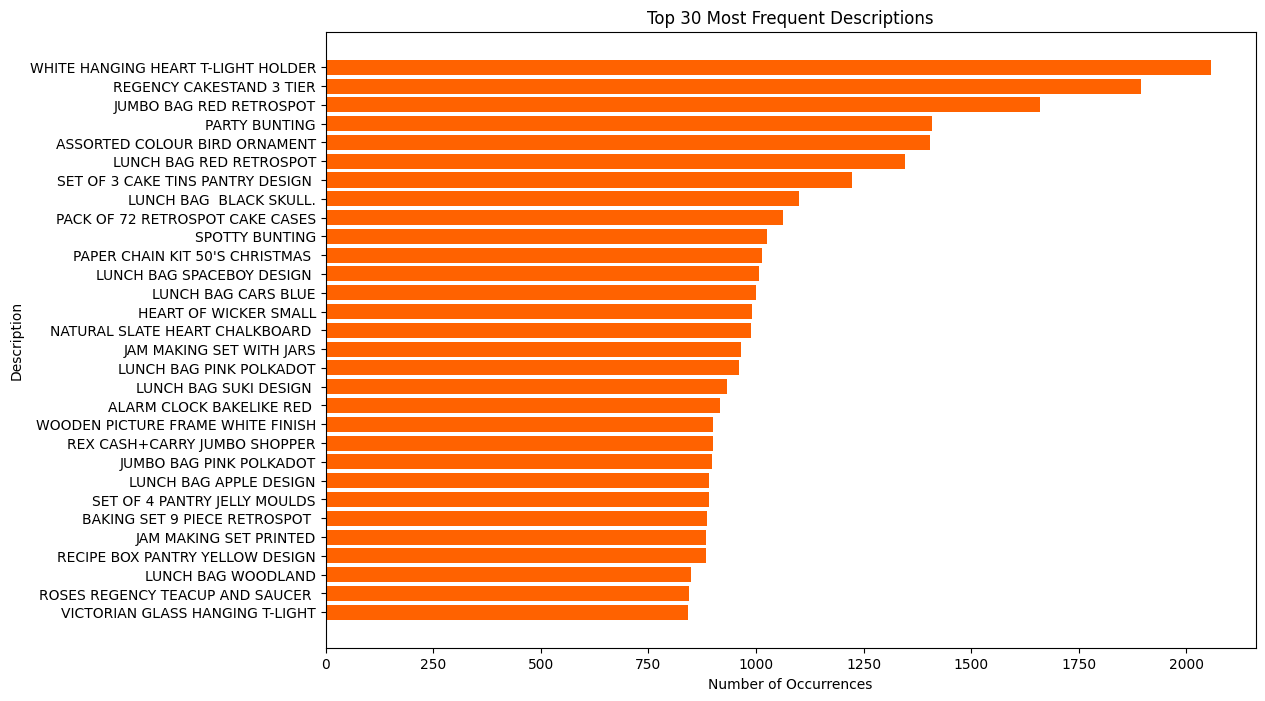

In [ ]:
import matplotlib.pyplot as plt
description_counts = df['Description'].value_counts()

# Get the top 30 descriptions
top_30_descriptions = description_counts[:30]

# Plotting
plt.figure(figsize=(12,8))
plt.barh(top_30_descriptions.index[::-1], top_30_descriptions.values[::-1], color='#ff6200')

# Adding labels and title
plt.xlabel('Number of Occurrences')
plt.ylabel('Description')
plt.title('Top 30 Most Frequent Descriptions')

# Show the plot
plt.show()



In [ ]:
df['UnitPrice'].describe()

,UnitPrice
count,399689.000000
mean,2.907457
std,4.451881
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,649.500000


In [ ]:
df = df[df['UnitPrice'] > 0]

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
for col in df.columns:
    unique_values = df[col].nunique()
    print(f"{col}: {unique_values} unique values")

InvoiceNo: 21785 unique values
StockCode: 3676 unique values
Description: 3888 unique values
Quantity: 431 unique values
InvoiceDate: 20132 unique values
UnitPrice: 372 unique values
CustomerID: 4362 unique values
Country: 37 unique values


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert InvoiceDate to datetime and extract only the date
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Find the most recent purchase date for each customer
customer_data = df.groupby('CustomerID')['InvoiceDay'].max().reset_index()

# Find the most recent date in the entire dataset
most_recent_date = df['InvoiceDay'].max()

# Convert InvoiceDay to datetime type before subtraction
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date = pd.to_datetime(most_recent_date)

# Calculate the number of days since the last purchase for each customer
customer_data['Days_Since_Last_Purchase'] = (most_recent_date - customer_data['InvoiceDay']).dt.days

# Remove the InvoiceDay column
customer_data.drop(columns=['InvoiceDay'], inplace=True)

In [ ]:
customer_data.head()

,CustomerID,Days_Since_Last_Purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310


In [ ]:
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns={'InvoiceNo': 'Total_Transactions'}, inplace=True)

# Calculate the total number of products purchased by each customer
total_products_purchased = df.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns={'Quantity': 'Total_Products_Purchased'}, inplace=True)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_transactions, on='CustomerID')
customer_data = pd.merge(customer_data, total_products_purchased, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,0
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196


In [ ]:
df['Total_Spend'] = df['UnitPrice'] * df['Quantity']
total_spend = df.groupby('CustomerID')['Total_Spend'].sum().reset_index()

# Calculate the average transaction value for each customer
average_transaction_value = total_spend.merge(total_transactions, on='CustomerID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_spend, on='CustomerID')
customer_data = pd.merge(customer_data, average_transaction_value[['CustomerID', 'Average_Transaction_Value']], on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,12346.0,325,2,0,0.00,0.000000
1,12347.0,2,7,2458,4310.00,615.714286
2,12348.0,75,4,2332,1437.24,359.310000
3,12349.0,18,1,630,1457.55,1457.550000
4,12350.0,310,1,196,294.40,294.400000


In [ ]:
#Calculate the number of unique products purchased by each customer
unique_products_purchased = df.groupby('CustomerID')['StockCode'].nunique().reset_index()
unique_products_purchased.rename(columns={'StockCode': 'Unique_Products_Purchased'}, inplace=True)

# Merge the new feature into the customer_data dataframe
customer_data = pd.merge(customer_data, unique_products_purchased, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,12346.0,325,2,0,0.00,0.000000,1
1,12347.0,2,7,2458,4310.00,615.714286,103
2,12348.0,75,4,2332,1437.24,359.310000,21
3,12349.0,18,1,630,1457.55,1457.550000,72
4,12350.0,310,1,196,294.40,294.400000,16


In [ ]:


# Calculate the average number of days between consecutive purchases
days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases = days_between_purchases.groupby('CustomerID').mean().reset_index()
average_days_between_purchases.rename(columns={'InvoiceDay': 'Average_Days_Between_Purchases'}, inplace=True)

/tmp/ipython-input-4145272268.py:2: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))


In [ ]:
customer_data = pd.merge(customer_data, average_days_between_purchases, on='CustomerID')

In [ ]:
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases
0,12346.0,325,2,0,0.00,0.000000,1,0.000000
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000
4,12350.0,310,1,196,294.40,294.400000,16,0.000000


In [ ]:
# Extract month and year from InvoiceDate
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

# Calculate monthly spending for each customer
monthly_spending = df.groupby(['CustomerID', 'Year', 'Month'])['Total_Spend'].sum().reset_index()

# Calculate Seasonal Buying Patterns: We are using monthly frequency as a proxy for seasonal buying patterns
seasonal_buying_patterns = monthly_spending.groupby('CustomerID')['Total_Spend'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean': 'Monthly_Spending_Mean', 'std': 'Monthly_Spending_Std'}, inplace=True)

# Replace NaN values in Monthly_Spending_Std with 0, implying no variability for customers with single transaction month
seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)
# Assuming your main customer DataFrame is named customer_df (aggregated by customer)
customer_data = customer_data.merge(seasonal_buying_patterns[['CustomerID', 'Monthly_Spending_Mean', 'Monthly_Spending_Std']], on='CustomerID', how='left')


/tmp/ipython-input-1199000979.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)


In [ ]:
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Monthly_Spending_Mean,Monthly_Spending_Std
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,0.000000,0.000000
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,615.714286,341.070789
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,359.310000,203.875689
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,1457.550000,0.000000
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,294.400000,0.000000


In [ ]:
# Get the most frequent country per customer
customer_country = df.groupby('CustomerID')['Country'].agg(lambda x: x.mode().iloc[0]).reset_index()

# Merge country info into customer_df
customer_data = customer_data.merge(customer_country, on='CustomerID', how='left')




In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4285 entries, 0 to 4284
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      4285 non-null   float64
 1   Days_Since_Last_Purchase        4285 non-null   int64  
 2   Total_Transactions              4285 non-null   int64  
 3   Total_Products_Purchased        4285 non-null   int64  
 4   Total_Spend                     4285 non-null   float64
 5   Average_Transaction_Value       4285 non-null   float64
 6   Unique_Products_Purchased       4285 non-null   int64  
 7   Average_Days_Between_Purchases  4285 non-null   float64
 8   Monthly_Spending_Mean           4285 non-null   float64
 9   Monthly_Spending_Std            4285 non-null   float64
 10  Country                         4285 non-null   object 
dtypes: float64(6), int64(4), object(1)
memory usage: 368.4+ KB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399656 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    399656 non-null  object        
 1   StockCode    399656 non-null  object        
 2   Description  399656 non-null  object        
 3   Quantity     399656 non-null  int64         
 4   InvoiceDate  399656 non-null  datetime64[ns]
 5   UnitPrice    399656 non-null  float64       
 6   CustomerID   399656 non-null  float64       
 7   Country      399656 non-null  object        
 8   InvoiceDay   399656 non-null  object        
 9   Total_Spend  399656 non-null  float64       
 10  Year         399656 non-null  int32         
 11  Month        399656 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(5)
memory usage: 36.6+ MB


In [ ]:
df.shape

(399656, 12)

In [ ]:
customer_data.shape

(4285, 11)

In [ ]:
#invoice based datset is turned into a customer based dataset

In [ ]:
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 4 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers), outliers

# Count outliers for Total_Spend
total_spend_outliers_count, total_spend_outliers = count_outliers(customer_data, 'Total_Spend')
print(f"Total_Spend outliers count: {total_spend_outliers_count}")

# Count outliers for Days_Since_Last_Purchase
days_last_purchase_outliers_count, days_last_purchase_outliers = count_outliers(customer_data, 'Days_Since_Last_Purchase')
print(f"Days_Since_Last_Purchase outliers count: {days_last_purchase_outliers_count}")

# Outliers combined (union)
combined_outliers = pd.concat([total_spend_outliers, days_last_purchase_outliers]).drop_duplicates()
print(f"Total combined outliers based on either metric: {len(combined_outliers)}")


Total_Spend outliers count: 155
Days_Since_Last_Purchase outliers count: 0
Total combined outliers based on either metric: 155


In [ ]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 4 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Remove outliers from Total_Spend
customer_data_no_outliers = remove_outliers_iqr(customer_data, 'Total_Spend')

# Remove outliers from Days_Since_Last_Purchase on the updated dataframe
customer_data_no_outliers = remove_outliers_iqr(customer_data_no_outliers, 'Days_Since_Last_Purchase')

print(f"Original data shape: {customer_data.shape}")
print(f"Shape after outlier removal: {customer_data_no_outliers.shape}")


Original data shape: (4285, 11)
Shape after outlier removal: (4130, 11)


In [ ]:
data = customer_data_no_outliers

In [ ]:


data['Country'].value_counts(normalize=True).head()



,proportion
Country,
United Kingdom,0.905569
Germany,0.021550
France,0.019613
Spain,0.006538
Belgium,0.005811


In [ ]:
# Binary encode Country: 1 if UK, else 0
data['Country_is_UK'] = data['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

# Check the result
print(data[['Country', 'Country_is_UK']].head(10))

data.drop(columns=['Country'], inplace=True)


          Country  Country_is_UK
0  United Kingdom              1
1         Iceland              0
2         Finland              0
3           Italy              0
4          Norway              0
5          Norway              0
6         Bahrain              0
7           Spain              0
8         Bahrain              0
9        Portugal              0


In [ ]:
data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Monthly_Spending_Mean,Monthly_Spending_Std,Country_is_UK
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,0.000000,0.000000,1
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,615.714286,341.070789,0
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,359.310000,203.875689,0
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,1457.550000,0.000000,0
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,294.400000,0.000000,0


In [ ]:
# Derived Features
data['Spend_per_Product'] = data['Total_Spend'] / (data['Total_Products_Purchased'] + 1e-6)
data['Transaction_Size'] = data['Total_Products_Purchased'] / (data['Total_Transactions'] + 1e-6)

# High Value Customer Flag (example threshold)
threshold = data['Average_Transaction_Value'].quantile(0.75)
data['High_Value_Customer'] = (data['Average_Transaction_Value'] > threshold).astype(int)

# Define Churn Label
churn_cutoff = 90
data['Churn'] = (data['Days_Since_Last_Purchase'] > churn_cutoff).astype(int)

# For CLV, if no future spend data, you can use Total_Spend as proxy
data['CLV_Proxy'] = data['Total_Spend']

In [ ]:
from sklearn.preprocessing import StandardScaler

# Columns to exclude from scaling
exclude_cols = ['CustomerID', 'Country_is_UK']

# Numeric columns to scale
cols_to_scale = [col for col in data.columns if col not in exclude_cols and data[col].dtype in ['float64', 'int64']]

scaler = StandardScaler()
data_scaled = data.copy()

# Fit and transform only the selected numeric columns
data_scaled[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

print(data_scaled.head())


   CustomerID  Days_Since_Last_Purchase  Total_Transactions  \
0     12346.0                  2.337961           -0.474400   
1     12347.0                 -0.903978            0.672715   
2     12348.0                 -0.171280           -0.015554   
3     12349.0                 -0.743386           -0.703823   
4     12350.0                  2.187406           -0.703823   

   Total_Products_Purchased  Total_Spend  Average_Transaction_Value  \
0                 -0.787159    -0.879877                  -1.048432   
1                  2.041890     2.530496                   1.126550   
2                  1.896869     0.257367                   0.220814   
3                 -0.062057     0.273438                   4.100296   
4                 -0.561572    -0.646928                  -0.008477   

   Unique_Products_Purchased  Average_Days_Between_Purchases  \
0                  -0.886177                       -0.300061   
1                   0.746840                       -0.126842   
2 

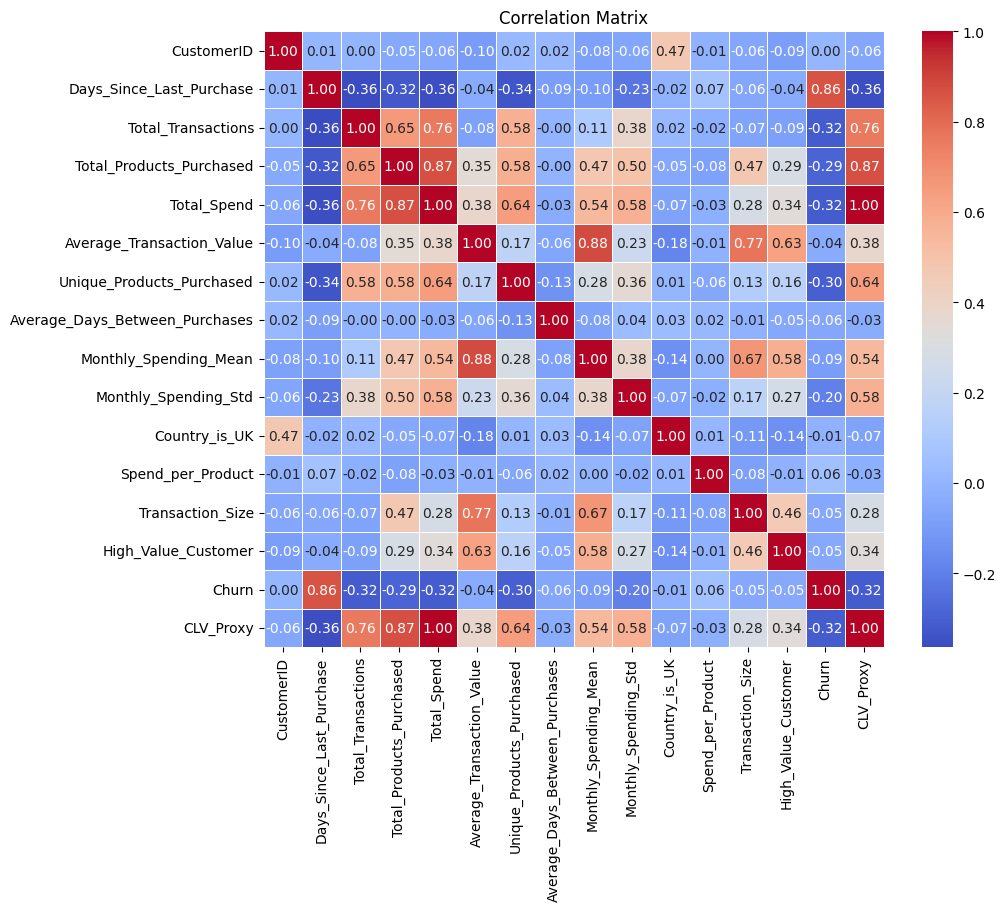

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = data_scaled.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
data_scaled.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Monthly_Spending_Mean,Monthly_Spending_Std,Country_is_UK,Spend_per_Product,Transaction_Size,High_Value_Customer,Churn,CLV_Proxy
0,12346.0,2.337961,-0.474400,-0.787159,-0.879877,-1.048432,-0.886177,-0.300061,-1.084140,-0.623713,1,-0.428589,-0.790158,-0.577537,1.410881,-0.879877
1,12347.0,-0.903978,0.672715,2.041890,2.530496,1.126550,0.746840,-0.126842,0.725802,0.998293,0,-0.072808,0.706980,1.731492,-0.708777,2.530496
2,12348.0,-0.171280,-0.015554,1.896869,0.257367,0.220814,-0.565978,0.634903,-0.027919,0.345844,0,-0.303538,1.695530,1.731492,-0.708777,0.257367
3,12349.0,-0.743386,-0.703823,-0.062057,0.273438,4.100296,0.250531,-0.300061,3.200446,-0.623713,0,0.040840,1.895918,1.731492,-0.708777,0.273438
4,12350.0,2.187406,-0.703823,-0.561572,-0.646928,-0.008477,-0.646028,-0.300061,-0.218727,-0.623713,0,-0.123821,0.045510,-0.577537,1.410881,-0.646928


In [ ]:
data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Monthly_Spending_Mean,Monthly_Spending_Std,Country_is_UK,Spend_per_Product,Transaction_Size,High_Value_Customer,Churn,CLV_Proxy
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,0.000000,0.000000,1,0.000000,0.000000,0,1,0.00
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,615.714286,341.070789,0,1.753458,351.142807,1,0,4310.00
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,359.310000,203.875689,0,0.616312,582.999854,1,0,1437.24
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,1457.550000,0.000000,0,2.313571,629.999370,1,0,1457.55
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,294.400000,0.000000,0,1.502041,195.999804,0,1,294.40


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [ 'Total_Transactions', 'Total_Products_Purchased',
            'Average_Transaction_Value', 'Unique_Products_Purchased', 'Average_Days_Between_Purchases',
             'Monthly_Spending_Std', 'Spend_per_Product', 'Monthly_Spending_Mean',
            'Transaction_Size', 'High_Value_Customer']

X = data_scaled[features]
y = data_scaled['CLV_Proxy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("linear Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2:", r2_score(y_test, y_pred))

linear Regressor
MAE: 0.15538110971073843
RMSE: 0.2736897317751009
R^2: 0.9275403088770011


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
features = [ 'Total_Transactions', 'Total_Products_Purchased',
            'Average_Transaction_Value', 'Unique_Products_Purchased', 'Average_Days_Between_Purchases',
             'Monthly_Spending_Std', 'Spend_per_Product',
            'Transaction_Size', 'High_Value_Customer']

X = data_scaled[features]
y = data_scaled['CLV_Proxy']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)


y_pred = rf_reg.predict(X_test)
print("Random Forest Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2:", r2_score(y_test, y_pred))

Random Forest Regressor
MAE: 0.02814680884620425
RMSE: 0.12553494545418376
R^2: 0.9847556557709299


              precision    recall  f1-score   support

           0       0.76      0.87      0.81       550
           1       0.63      0.46      0.53       276

    accuracy                           0.73       826
   macro avg       0.70      0.66      0.67       826
weighted avg       0.72      0.73      0.72       826

ROC AUC: 0.7732345191040844


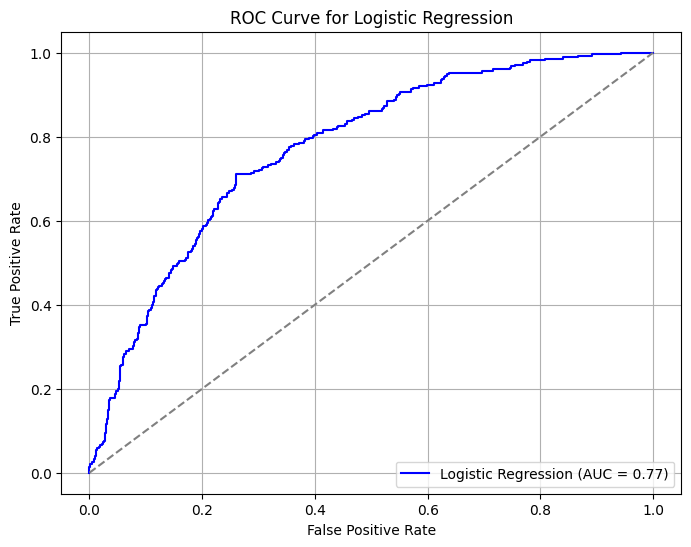

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split


y_cls = data['Churn']


X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)


logr = LogisticRegression(max_iter=1000)


logr.fit(X_train_cls, y_train_cls)


y_pred_cls = logr.predict(X_test_cls)
y_proba_cls = logr.predict_proba(X_test_cls)[:,1]


print(classification_report(y_test_cls, y_pred_cls))


roc_auc = roc_auc_score(y_test_cls, y_proba_cls)
print("ROC AUC:", roc_auc)


fpr, tpr, thresholds = roc_curve(y_test_cls, y_proba_cls)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.title('ROC Curve for Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


              precision    recall  f1-score   support

           0       0.74      0.85      0.79       550
           1       0.57      0.39      0.46       276

    accuracy                           0.70       826
   macro avg       0.65      0.62      0.63       826
weighted avg       0.68      0.70      0.68       826

ROC AUC: 0.7527239789196312


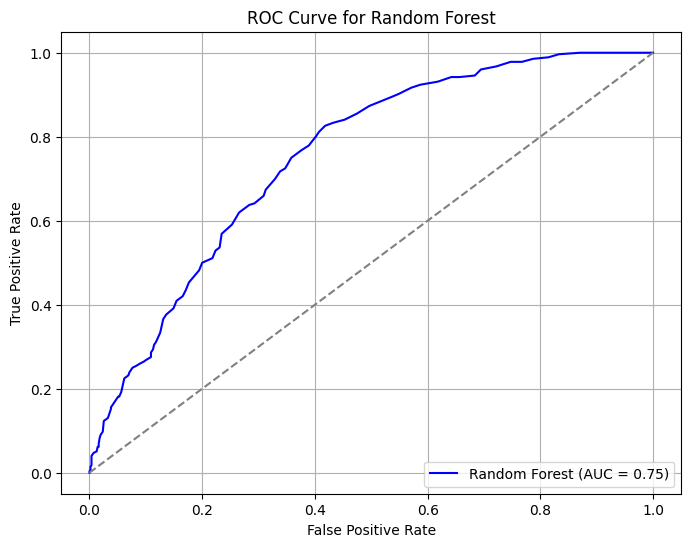

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve


features = [ 'Total_Transactions', 'Total_Products_Purchased',
            'Average_Transaction_Value', 'Unique_Products_Purchased', 'Average_Days_Between_Purchases',
            'Monthly_Spending_Mean', 'Monthly_Spending_Std', 'Spend_per_Product',
            'Transaction_Size', 'High_Value_Customer']

X = data[features]
y = data['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


print(classification_report(y_test, y_pred))


roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve for Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
